线性模型
输入$\mathbf{x}=[x_1,x_2,\cdots,x_n]^T$

输出为$y=\left \langle \mathbf{x},\mathbf{w} \right \rangle +b$

$$\begin{aligned}\ell(\mathbf{X}, \mathbf{y}, \mathbf{w}, b)&=\frac{1}{2 n} \sum_{i=1}^{n}\left(y_{i}-\left\langle\mathbf{x}_{i}, \mathbf{w}\right\rangle-b\right)^{2} \\ &=\frac{1}{2 n}\|\mathbf{y}-\mathbf{X} \mathbf{w}-b\|^{2}\end{aligned}$$

将bias加入$\bf w$中
$\bf x\leftarrow[x,1],w\leftarrow [w,b]$


In [1]:
import torch
from matplotlib import pyplot as plt
import numpy as np

c:\Users\19234\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


例: $y=2x+1$

$$\mathbf{x}=[x_i,1]\\
\mathbf{y}=\mathbf{x}[a,b]$$


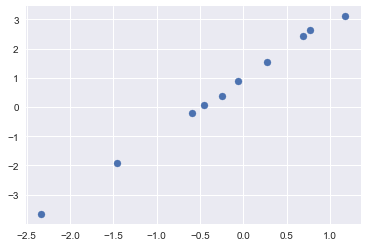

In [2]:
#构造数据集
num=10
para_num=2#参数数量(x_1,x_2,……,b)
w=torch.tensor([2.,1.])#参数数值

def train_data(num,para_num,w):
    x=torch.ones(num,para_num)
    norm_x=torch.normal(0,1,(num,para_num-1))
    x[:,:para_num-1]=norm_x[:,:para_num-1]
    y=torch.mv(x,w)+torch.normal(0,0.1,(num,1))[:,0]
    return(x,y)

a=train_data(num,para_num,w)
plt.style.use('seaborn')
fig,ax=plt.subplots()
x=a[0]
y=a[1]
ax.scatter(a[0][:,0],a[1])


In [3]:
w1=torch.rand(2,requires_grad=True)#初始
lr=0.01#学习率
epochs=100

In [4]:
# 梯度下降算法

def sgd(para_num,epochs,lr,w,x,y):
    res=torch.zeros(epochs,para_num+1)#还有loss
    for epoch in range(epochs):
        loss=(torch.mv(x,w)-y)**2#loss函数
        loss.sum().backward()
        res[epoch,:para_num]=w.detach()
        res[epoch,para_num]=loss.sum().detach()
        with torch.no_grad():#更新时不用计算梯度
            #非常重要
            w-=(w.grad)*lr
            w.grad.zero_()  
    return res
ans=sgd(2,epochs,lr,w1,x,y)
ans

tensor([[ 0.0762,  0.8474, 38.1440],
        [ 0.4794,  0.7853, 23.3938],
        [ 0.7934,  0.7538, 14.5444],
        [ 1.0387,  0.7426,  9.1725],
        [ 1.2310,  0.7447,  5.8703],
        [ 1.3821,  0.7551,  3.8138],
        [ 1.5013,  0.7701,  2.5162],
        [ 1.5957,  0.7875,  1.6866],
        [ 1.6706,  0.8057,  1.1496],
        [ 1.7303,  0.8236,  0.7979],
        [ 1.7780,  0.8406,  0.5651],
        [ 1.8163,  0.8563,  0.4095],
        [ 1.8470,  0.8707,  0.3046],
        [ 1.8718,  0.8835,  0.2334],
        [ 1.8919,  0.8949,  0.1847],
        [ 1.9082,  0.9049,  0.1513],
        [ 1.9214,  0.9136,  0.1283],
        [ 1.9322,  0.9212,  0.1123],
        [ 1.9410,  0.9278,  0.1012],
        [ 1.9483,  0.9334,  0.0935],
        [ 1.9542,  0.9382,  0.0881],
        [ 1.9591,  0.9424,  0.0844],
        [ 1.9631,  0.9459,  0.0818],
        [ 1.9664,  0.9489,  0.0799],
        [ 1.9692,  0.9515,  0.0786],
        [ 1.9714,  0.9536,  0.0777],
        [ 1.9733,  0.9555,  0.0771],
 

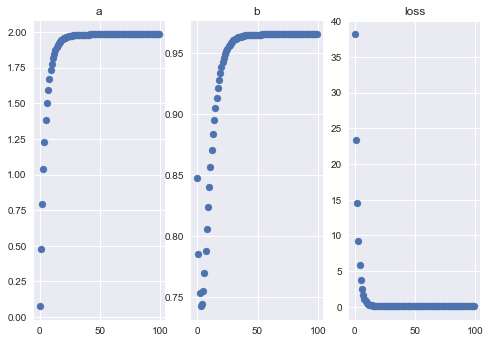

In [5]:
plt.style.use('seaborn')
fig,ax=plt.subplots(1,3)
ax[0].set_title('a')
ax[1].set_title('b')
ax[2].set_title('loss')

for i in range(3):
    ax[i].scatter(range(epochs),[a[i] for a in ans])




$$y=2x_1-3.4x_2+4.2$$

In [6]:
para_num=3
t=train_data(10,3,torch.tensor([2.,-3.4,4.2]))


In [7]:
w1=torch.rand(para_num,requires_grad=True)#初始
lr=0.01#学习率
epochs=300

In [8]:
sgd(para_num,epochs,lr,w1,t[0],t[1])

tensor([[ 1.8641e-01,  8.9978e-01,  9.6584e-01,  6.7322e+02],
        [ 6.9732e-01, -1.3605e+00,  1.8264e+00,  2.0395e+02],
        [ 9.7168e-01, -2.5372e+00,  2.3784e+00,  6.7779e+01],
        ...,
        [ 1.9876e+00, -3.4469e+00,  4.1250e+00,  4.5175e-02],
        [ 1.9876e+00, -3.4469e+00,  4.1250e+00,  4.5175e-02],
        [ 1.9876e+00, -3.4469e+00,  4.1250e+00,  4.5175e-02]])

In [9]:
from torch.utils import data
#利用api简洁实现 

t=train_data(10,3,torch.tensor([2.,-3.4,4.2]))
feature,lables=t[0][:,:para_num-1],t[1].unsqueeze(-1)#去除齐次坐标

#注意unsqueeze(-1)用于从[10]升维成[10,1]

def load_array(data_array,batch_size,is_train=True):
    dataset=data.TensorDataset(*data_array)#给元组解包
    return data.DataLoader(dataset,batch_size,shuffle=is_train)#随机挑选batch_size个

batch_size=10
data_iter=load_array((feature,lables),batch_size,True)

feature.shape,lables.shape,next(iter(data_iter))


(torch.Size([10, 2]),
 torch.Size([10, 1]),
 [tensor([[ 3.2985,  0.9272],
          [-0.2736, -0.1052],
          [-0.0058, -0.1298],
          [-0.4851, -0.5652],
          [-1.8301, -1.2931],
          [-0.0364,  1.2634],
          [-1.5251, -0.1215],
          [ 0.2902,  0.0924],
          [-1.3072, -0.7338],
          [-0.2068, -0.9528]]),
  tensor([[ 7.6185],
          [ 4.0073],
          [ 4.4766],
          [ 5.1270],
          [ 5.0118],
          [-0.2926],
          [ 1.5002],
          [ 4.5675],
          [ 4.1490],
          [ 7.0662]])])

In [10]:
from torch import nn

net=nn.Sequential(nn.Linear(2,1))#输入为2,输出为1
#放在序列内

In [11]:
net[0].weight.data.normal_(0,0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [12]:
loss=nn.MSELoss()#Mean Square Error

#实例化Stochastic Gradient Descent(SGD)随机梯度下降
trainer=torch.optim.SGD(net.parameters(),lr=0.03)

for epoch in range(epochs):
    for X, y in data_iter:
        l = loss(net(X) ,y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(feature), lables)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 21.169468
epoch 2, loss 19.035639
epoch 3, loss 17.142994
epoch 4, loss 15.461777
epoch 5, loss 13.966345
epoch 6, loss 12.634504
epoch 7, loss 11.446974
epoch 8, loss 10.386950
epoch 9, loss 9.439748
epoch 10, loss 8.592491
epoch 11, loss 7.833879
epoch 12, loss 7.153961
epoch 13, loss 6.543967
epoch 14, loss 5.996158
epoch 15, loss 5.503690
epoch 16, loss 5.060508
epoch 17, loss 4.661248
epoch 18, loss 4.301156
epoch 19, loss 3.976014
epoch 20, loss 3.682079
epoch 21, loss 3.416022
epoch 22, loss 3.174889
epoch 23, loss 2.956052
epoch 24, loss 2.757172
epoch 25, loss 2.576169
epoch 26, loss 2.411191
epoch 27, loss 2.260587
epoch 28, loss 2.122889
epoch 29, loss 1.996786
epoch 30, loss 1.881110
epoch 31, loss 1.774818
epoch 32, loss 1.676983
epoch 33, loss 1.586773
epoch 34, loss 1.503448
epoch 35, loss 1.426345
epoch 36, loss 1.354872
epoch 37, loss 1.288501
epoch 38, loss 1.226757
epoch 39, loss 1.169217
epoch 40, loss 1.115501
epoch 41, loss 1.065268
epoch 42, loss 1.

In [17]:
net[0].weight.data,net[0].bias.data

(tensor([[ 2.0093, -3.4588]]), tensor([4.1822]))